**EL5206 Laboratorio de Inteligencia Computacional y Robótica**

In [143]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import random
import math

In [144]:
# Cargamos los datos del laser
my_array = np.load('gt.npy')
# my_array = np.load('odom.npy')
print(my_array)

[[ 2.39060224  0.84330792]
 [ 2.32827095  0.85196129]
 [ 2.24272597  0.84676674]
 ...
 [ 6.1730913  -5.22984143]
 [ 6.23023698 -5.23765266]
 [ 6.28762084 -5.21214495]]


In [145]:
#Eliminamos los elementos que se van a infinito
new_array = []
for i in range(len(my_array)):

  if my_array[i][0] != np.inf:
    new_array.append(my_array[i])
new_array = np.array(new_array)

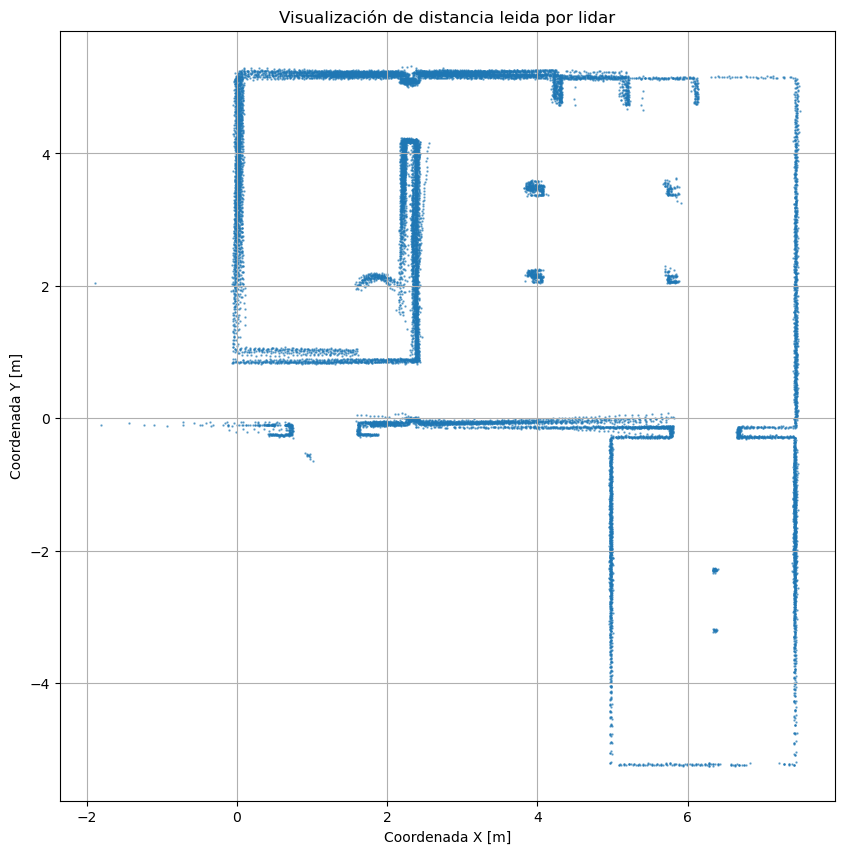

In [146]:
# Mostramos las mediciones en un gráfico
x = []
y = []
for i in range(len(new_array)):
  x.append(new_array[i][0])
  y.append(new_array[i][1])

cartesianas = new_array
plt.figure(figsize=(10,10)) 
plt.scatter(x, y, alpha=0.6, s=0.5)
plt.grid(True)
plt.xlabel('Coordenada X [m]')
plt.ylabel('Coordenada Y [m]')
plt.title('Visualización de distancia leida por lidar')

plt.show()

In [147]:
def distancia_punto_a_recta(punto, m, n):
    # Calcula la distancia entre un punto y una recta
    x, y = punto
    distancia = np.abs(m * x - y + n) / np.sqrt(m**2 + 1)
    return distancia

In [148]:
def line_from_points(p1, p2):
    (x1, y1), (x2, y2) = p1, p2
  # COMPLETAR con la ecuación de la recta de toda la vida
  ## Recta a*x + b*y + c = 0 normalizada (c >= 0) a partir de 2 puntos.

    a = (y1 - y2) / (x2 -x1)
    b = 1
    c = -a*x1-y1
    norm = math.hypot(a, b)
    if norm == 0:
        return None
    a, b, c = a/norm, b/norm, c/norm
    if c < 0:  # consistencia de signos
        a, b, c = -a, -b, -c
    return (a, b, c)

In [149]:
def mn_from_abc(a, b, c):
    if b == 0:
        return float('inf'), float('inf')  # Línea vertical
    m = -a / b
    n = -c / b
    return m, n

In [150]:
def RANSAC(points, dist_thresh, min_inliers, max_iter, max_lines):
    lines = []
    points = np.array(points)  # aseguramos que es array numpy

    for _ in range(max_iter):
        if len(points) < 2:  # no quedan suficientes puntos
            break

        # Elegimos dos puntos aleatorios
        idx = np.random.choice(len(points), 2, replace=False)
        point_1, point_2 = points[idx]

        # Ecuación de la recta
        line = line_from_points(point_1, point_2)
        if line is None:
            continue

        # Distancia de todos los puntos a la recta
        distances = np.abs(line[0]*points[:,0] + line[1]*points[:,1] + line[2])

        # Inliers y outliers
        inliers_mask = distances < dist_thresh
        inliers = points[inliers_mask]
        points = points[~inliers_mask]  # descartamos los inliers

        # Guardamos línea si tiene suficientes inliers
        if len(inliers) >= min_inliers:
            lines.append(line)
            if len(lines) >= max_lines:
                break

    mn_list = []
    for line in lines:
        mn = mn_from_abc(line[0], line[1], line[2])
        mn_list.append(mn)
    return mn_list

In [151]:
def RANSAC(points, dist_thresh, min_inliers, max_iter, max_lines):
    lines = []
    points = np.array(points)  # aseguramos que es array numpy
    for _ in range(max_lines):
        for _ in range(max_iter):
            if len(points) < 2:  # no quedan suficientes puntos
                break

            # Elegimos dos puntos aleatorios
            idx = np.random.choice(len(points), 2, replace=False)
            point_1, point_2 = points[idx]

            # Ecuación de la recta
            line = line_from_points(point_1, point_2)
            if line is None:
                continue

            # Distancia de todos los puntos a la recta
            distances = np.abs(line[0]*points[:,0] + line[1]*points[:,1] + line[2])

            # Inliers y outliers
            inliers_mask = distances < dist_thresh
            inliers = points[inliers_mask]
            points = points[~inliers_mask]  # descartamos los inliers

            # Guardamos línea si tiene suficientes inliers
            if len(inliers) >= min_inliers:
                lines.append(line)
                break
        if len(lines) >= max_lines:
            break
        # return lines
    mn_list = []
    for line in lines:
        mn = mn_from_abc(line[0], line[1], line[2])
        mn_list.append(mn)
    return mn_list


In [ ]:
# TEST
def RANSAC(points, dist_thresh, min_inliers, max_iter, max_lines=1):
    """
    Implementación de RANSAC que sigue exactamente el algoritmo descrito.
    
    Args:
        points: Lista o array de puntos [(x1,y1), (x2,y2), ...]
        dist_thresh: Tolerancia para considerar un punto como inlier
        min_inliers: Número mínimo de puntos (K) para aceptar una línea
        max_iter: Número máximo de iteraciones (L) por línea
        max_lines: Número máximo de líneas a extraer (default=1 para algoritmo original)
    
    Returns:
        - Si max_lines=1: tuple (line_params, success)
          line_params: [m, n] donde y = mx + n, o None si falla
          success: True si se encontró línea válida, False si falló
        - Si max_lines>1: list de parámetros de líneas [[m1, n1], [m2, n2], ...]
    """
    points = np.array(points.copy() if hasattr(points, 'copy') else list(points))
    lines_found = []
    
    # Bucle para extraer múltiples líneas
    for line_iteration in range(max_lines):
        
        # Verificar que quedan suficientes puntos para formar una línea
        if len(points) < 2:
            break
        
        line_found = False
        best_line = None
        
        # Algoritmo RANSAC para una línea (pasos 1-6)
        for iteration in range(max_iter):
            
            # Paso 1: Seleccionar aleatoriamente 2 lecturas de rango del láser
            if len(points) < 2:
                break
                
            idx = np.random.choice(len(points), 2, replace=False)
            point_1, point_2 = points[idx]
            
            # Paso 2: Encontrar la línea que cruza ambos puntos
            line = line_from_points(point_1, point_2)
            if line is None:  # Línea degenerada (puntos idénticos)
                continue
            
            # Paso 3: Encontrar los K puntos que pertenecen a esta línea, dada una tolerancia
            distances = np.abs(line[0]*points[:,0] + line[1]*points[:,1] + line[2])
            inliers_mask = distances < dist_thresh
            num_inliers = np.sum(inliers_mask)
            
            # Paso 4: Si K es suficientemente grande, aceptar la línea y terminar algoritmo
            if num_inliers >= min_inliers:
                # Convertir parámetros ABC a formato mx + n
                mn = mn_from_abc(line[0], line[1], line[2])
                best_line = mn
                line_found = True
                
                # Remover inliers para próxima línea (solo si buscamos múltiples líneas)
                if max_lines > 1:
                    points = points[~inliers_mask]
                
                break  # Terminar iteraciones para esta línea
        
        # Paso 6: Verificar si se encontró línea o si hubo detección fallida
        if line_found:
            lines_found.append(best_line)
        else:
            # Si no se encuentra línea tras L iteraciones, detección fallida
            break
    
    # Retornar según el número de líneas solicitadas
    if max_lines == 1:
        # Comportamiento original del algoritmo: una sola línea
        if len(lines_found) > 0:
            return lines_found[0], True
        else:
            return None, False
    else:
        # Múltiples líneas: retornar lista
        return lines_found

[(np.float64(-10.460422779936396), np.float64(4.649922697801823)), (np.float64(0.043112886983343666), np.float64(5.1345061099478)), (np.float64(0.007159597167546307), np.float64(-0.10715692083178463)), (np.float64(331.08479443812325), np.float64(-2460.313007619877))]


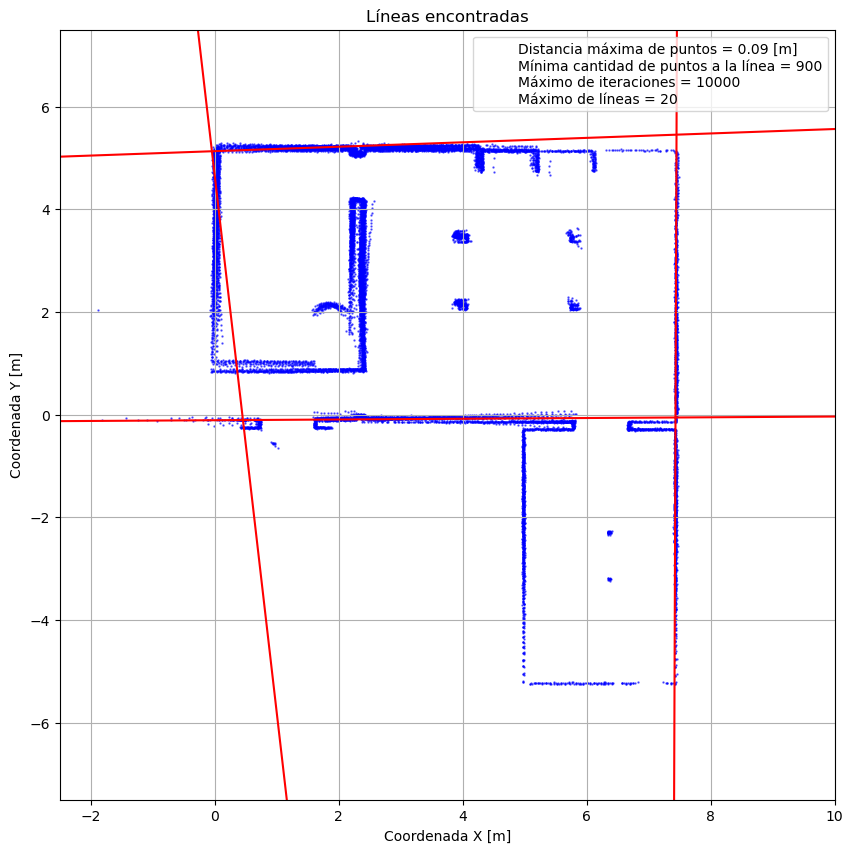

In [169]:

dist_tresh = 0.09
min_inliers = 900
max_iter = 10000
max_lines = 20
mn = RANSAC(cartesianas, dist_tresh, min_inliers, max_iter, max_lines)
print(mn)

plt.figure(figsize=(10,10))
plt.xlim(-2.5,10)
plt.ylim(-7.5,7.5)

params_text = (
    f"Distancia máxima de puntos = {dist_tresh} [m]\n"
    f"Mínima cantidad de puntos a la línea = {min_inliers}\n"
    f"Máximo de iteraciones = {max_iter}\n"
    f"Máximo de líneas = {max_lines}"
)

for line in mn:
    m, n = line
    x = np.linspace(-10, 10, 100)
    y = m * x + n
    plt.plot(x, y, color='red')

px = [x[0] for x in cartesianas]
py = [x[1] for x in cartesianas]
plt.scatter(px, py, color='blue', alpha=0.6, s=0.5)

custom_legend = [Line2D([0], [0], color='none', label=params_text)]

plt.xlabel('Coordenada X [m]')
plt.ylabel('Coordenada Y [m]')
plt.title('Líneas encontradas')
plt.legend(handles=custom_legend, loc="upper right", frameon=True)
plt.grid(True)
plt.show()


[(np.float64(34.825560629077664), np.float64(-72.8148456302102)), (np.float64(-1306.8296342406309), np.float64(9707.6666272321)), (np.float64(-0.018256548716157537), np.float64(5.238328271132867)), (np.float64(-96.91828043665782), np.float64(478.9165878648727)), (np.float64(0.03982060241219719), np.float64(5.104461024848488)), (np.float64(-1576.1847212943228), np.float64(3746.8507041256003)), (np.float64(-0.09473836053378927), np.float64(0.22098785080801467)), (np.float64(0.0075150743672977105), np.float64(5.157501947193878)), (np.float64(0.02819405815214657), np.float64(-0.1422879079185811)), (np.float64(-0.005544916030618716), np.float64(-0.10612167029371068)), (np.float64(-0.027329956254880203), np.float64(5.234021706091526)), (np.float64(774.9046544335588), np.float64(-13.745117305089455)), (np.float64(-0.0044081069614372555), np.float64(-0.050775177994799546))]


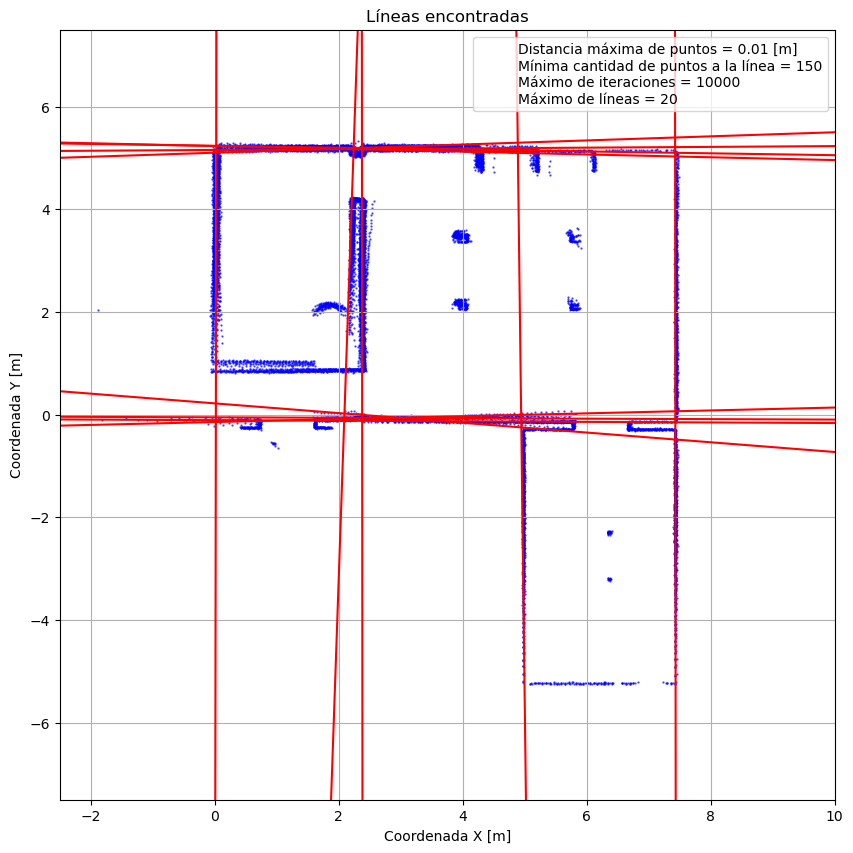

In [172]:
dist_tresh = 0.01
min_inliers = 150
max_iter = 10000
max_lines = 20

mn = RANSAC(cartesianas, dist_tresh, min_inliers, max_iter, max_lines)
print(mn)

plt.figure(figsize=(10,10))
plt.xlim(-2.5,10)
plt.ylim(-7.5,7.5)

params_text = (
    f"Distancia máxima de puntos = {dist_tresh} [m]\n"
    f"Mínima cantidad de puntos a la línea = {min_inliers}\n"
    f"Máximo de iteraciones = {max_iter}\n"
    f"Máximo de líneas = {max_lines}"
)

for line in mn:
    m, n = line
    x = np.linspace(-10, 10, 100)
    y = m * x + n
    plt.plot(x, y, color='red')

px = [x[0] for x in cartesianas]
py = [x[1] for x in cartesianas]
plt.scatter(px, py, color='blue', alpha=0.6, s=0.5)

custom_legend = [Line2D([0], [0], color='none', label=params_text)]

plt.xlabel('Coordenada X [m]')
plt.ylabel('Coordenada Y [m]')
plt.title('Líneas encontradas')
plt.legend(handles=custom_legend, loc="upper right", frameon=True)
plt.grid(True)
plt.show()
